# Notebook 2 — Data Preparation and Claim-Level Feature Engineering

This notebook:
- loads the outpatient claims table from Google Drive
- audits schema, missingness, and claim grain
- standardizes dates, numeric fields, and code fields
- builds a clean claim-level analytical table
- creates thesis-core baseline features
- saves reusable processed outputs for later notebooks

The notebook is intentionally limited to **data preparation and baseline feature engineering**.
It does **not** perform train/test splitting or modeling.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#Cell 1 - Load libraries and project paths
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

THESIS_ROOT = Path('/content/drive/MyDrive/NyanThesisAnomaly')

with open(THESIS_ROOT / 'project_paths.json', 'r', encoding='utf-8') as f:
    PROJECT_PATHS = json.load(f)

DATA_RAW_DIR = Path(PROJECT_PATHS['DATA_RAW_DIR'])
DATA_INTERIM_DIR = Path(PROJECT_PATHS['DATA_INTERIM_DIR'])
DATA_PROCESSED_DIR = Path(PROJECT_PATHS['DATA_PROCESSED_DIR'])
OUTPUTS_DIR = Path(PROJECT_PATHS['OUTPUTS_DIR'])
TABLES_DIR = Path(PROJECT_PATHS['TABLES_DIR'])
FIGURES_DIR = Path(PROJECT_PATHS['FIGURES_DIR'])
NOTEBOOK_EXPORTS_DIR = Path(PROJECT_PATHS['NOTEBOOK_EXPORTS_DIR'])
PHASE1_DIR = Path(PROJECT_PATHS['PHASE1_DIR'])

RAW_CSV_PATH = DATA_RAW_DIR / 'kaggle_cms_desynpuf_2010_outpatient_claims' / 'desynpuf_outpatient_claims_2010_filtered.csv'

print('Raw CSV path:', RAW_CSV_PATH)
print('Processed data dir:', DATA_PROCESSED_DIR)


Raw CSV path: /content/drive/MyDrive/NyanThesisAnomaly/data/raw/kaggle_cms_desynpuf_2010_outpatient_claims/desynpuf_outpatient_claims_2010_filtered.csv
Processed data dir: /content/drive/MyDrive/NyanThesisAnomaly/data/processed


In [6]:
#Cell 2 - Load the raw outpatient claims dataset
df_raw = pd.read_csv(RAW_CSV_PATH, low_memory=False)

print('Raw shape:', df_raw.shape)
display(df_raw.head())


Raw shape: (175005, 76)


,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,...,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
0,00024B3D2352D2D0,542372281246633,1,2010-05-26,2010-05-26,5200YU,40.0,0.0,5.972737e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0002F28CE057345B,542702280893497,1,2010-04-28,2010-04-28,3900RQ,50.0,0.0,3.981877e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000345A39D4157C9,542712281107503,1,2010-08-01,2010-08-01,2300CS,90.0,0.0,2.146330e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,000489E7EAAD463F,542912281339207,1,2010-12-12,2010-12-12,1513WQ,300.0,0.0,2.462820e+09,2.462820e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0007F12A492FD25D,542862281135179,1,2010-01-24,2010-01-24,4200BS,200.0,0.0,4.341916e+09,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Cell 3 - Inspect schema, data types, and missingness
schema_df = pd.DataFrame({
    'column': df_raw.columns,
    'dtype_raw': df_raw.dtypes.astype(str).values,
    'missing_count': df_raw.isna().sum().values,
    'missing_pct': (df_raw.isna().mean() * 100).round(2).values,
})

display(schema_df.sort_values(['missing_pct', 'column'], ascending=[False, True]).head(40))

schema_out_path = TABLES_DIR / '02_raw_schema_and_missingness.csv'
schema_df.to_csv(schema_out_path, index=False)

print('Saved schema audit to:', schema_out_path)


,column,dtype_raw,missing_count,missing_pct
75,HCPCS_CD_45,float64,175005,100.00
26,ICD9_PRCDR_CD_5,object,174999,100.00
27,ICD9_PRCDR_CD_6,float64,175000,100.00
23,ICD9_PRCDR_CD_2,object,174981,99.99
24,ICD9_PRCDR_CD_3,object,174990,99.99
25,ICD9_PRCDR_CD_4,object,174995,99.99
22,ICD9_PRCDR_CD_1,float64,174960,99.97
21,ICD9_DGNS_CD_10,object,174291,99.59
74,HCPCS_CD_44,object,172451,98.54
73,HCPCS_CD_43,object,172302,98.46


Saved schema audit to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_raw_schema_and_missingness.csv


In [8]:
#Cell 4 - Define column groups used throughout the notebook
ID_COLS = [
    'DESYNPUF_ID', 'CLM_ID', 'SEGMENT', 'PRVDR_NUM',
    'AT_PHYSN_NPI', 'OP_PHYSN_NPI', 'OT_PHYSN_NPI'
]

DATE_COLS = ['CLM_FROM_DT', 'CLM_THRU_DT']

PAYMENT_COLS = [
    'CLM_PMT_AMT',
    'NCH_PRMRY_PYR_CLM_PD_AMT',
    'NCH_BENE_BLOOD_DDCTBL_LBLTY_AM',
    'NCH_BENE_PTB_DDCTBL_AMT',
    'NCH_BENE_PTB_COINSRNC_AMT'
]

DIAG_COLS = [c for c in df_raw.columns if c.startswith('ICD9_DGNS_CD_')]
PROC_COLS = [c for c in df_raw.columns if c.startswith('ICD9_PRCDR_CD_')]
HCPCS_COLS = [c for c in df_raw.columns if c.startswith('HCPCS_CD_')]
ADMIT_COLS = ['ADMTNG_ICD9_DGNS_CD']

print('Diagnosis columns:', len(DIAG_COLS))
print('Procedure columns:', len(PROC_COLS))
print('HCPCS columns:', len(HCPCS_COLS))


Diagnosis columns: 10
Procedure columns: 6
HCPCS columns: 45


In [9]:
#Cell 5 - Make a working copy and standardize obvious string placeholders
df = df_raw.copy()

STRING_LIKE_COLS = [c for c in ID_COLS + DATE_COLS + DIAG_COLS + PROC_COLS + HCPCS_COLS + ADMIT_COLS if c in df.columns]

for col in STRING_LIKE_COLS:
    df[col] = df[col].astype('string').str.strip()

PLACEHOLDER_VALUES = {
    '': pd.NA,
    'nan': pd.NA,
    'None': pd.NA,
    'NONE': pd.NA,
    'NULL': pd.NA,
    'NaN': pd.NA,
}

for col in STRING_LIKE_COLS:
    df[col] = df[col].replace(PLACEHOLDER_VALUES)

display(df[STRING_LIKE_COLS[:10]].head())


,DESYNPUF_ID,CLM_ID,SEGMENT,PRVDR_NUM,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,CLM_FROM_DT,CLM_THRU_DT,ICD9_DGNS_CD_1
0,00024B3D2352D2D0,542372281246633,1,5200YU,5972737463.0,<NA>,<NA>,2010-05-26,2010-05-26,V821
1,0002F28CE057345B,542702280893497,1,3900RQ,3981876528.0,<NA>,<NA>,2010-04-28,2010-04-28,7210
2,000345A39D4157C9,542712281107503,1,2300CS,2146329983.0,<NA>,2146329983.0,2010-08-01,2010-08-01,V4366
3,000489E7EAAD463F,542912281339207,1,1513WQ,2462820318.0,2462820318.0,<NA>,2010-12-12,2010-12-12,9224
4,0007F12A492FD25D,542862281135179,1,4200BS,4341915698.0,<NA>,<NA>,2010-01-24,2010-01-24,20302


In [10]:
#Cell 6 - Convert dates and derive a clean claim date range
for col in DATE_COLS:
    df[col] = pd.to_datetime(df[col], errors='coerce')

date_quality = pd.DataFrame({
    'column': DATE_COLS,
    'missing_count': [df[c].isna().sum() for c in DATE_COLS],
    'min_date': [df[c].min() for c in DATE_COLS],
    'max_date': [df[c].max() for c in DATE_COLS],
})

display(date_quality)

date_quality_path = TABLES_DIR / '02_date_quality_summary.csv'
date_quality.to_csv(date_quality_path, index=False)
print('Saved date-quality summary to:', date_quality_path)


,column,missing_count,min_date,max_date
0,CLM_FROM_DT,0,2009-12-12,2010-12-31
1,CLM_THRU_DT,0,2010-01-01,2010-12-31


Saved date-quality summary to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_date_quality_summary.csv


In [11]:
#Cell 7 - Convert payment-related columns to numeric
for col in PAYMENT_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

payment_summary = df[PAYMENT_COLS].describe().T
display(payment_summary)

payment_summary_path = TABLES_DIR / '02_payment_summary.csv'
payment_summary.to_csv(payment_summary_path)
print('Saved payment summary to:', payment_summary_path)


,count,mean,std,min,25%,50%,75%,max
CLM_PMT_AMT,175005.0,278.593297,560.317965,-100.0,40.0,80.0,200.0,3300.0
NCH_PRMRY_PYR_CLM_PD_AMT,175005.0,8.867918,199.751233,0.0,0.0,0.0,0.0,14000.0
NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,175005.0,0.008571,1.772770,0.0,0.0,0.0,0.0,500.0
NCH_BENE_PTB_DDCTBL_AMT,175005.0,3.034199,17.522852,0.0,0.0,0.0,0.0,200.0
NCH_BENE_PTB_COINSRNC_AMT,175005.0,81.208423,176.867119,0.0,0.0,20.0,70.0,1100.0


Saved payment summary to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_payment_summary.csv


In [12]:
#Cell 8 - Check claim grain and create a stable claim key
df['CLAIM_KEY'] = df['CLM_ID'].astype('Int64').astype(str) + '_' + df['SEGMENT'].astype('Int64').astype(str)

grain_check = pd.DataFrame({
    'metric': ['row_count', 'unique_clm_id', 'unique_claim_key', 'duplicate_claim_key_rows'],
    'value': [
        len(df),
        df['CLM_ID'].nunique(dropna=True),
        df['CLAIM_KEY'].nunique(dropna=True),
        int(df['CLAIM_KEY'].duplicated().sum()),
    ]
})

display(grain_check)

grain_check_path = TABLES_DIR / '02_claim_grain_check.csv'
grain_check.to_csv(grain_check_path, index=False)
print('Saved grain check to:', grain_check_path)


,metric,value
0,row_count,175005
1,unique_clm_id,175005
2,unique_claim_key,175005
3,duplicate_claim_key_rows,0


Saved grain check to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_claim_grain_check.csv


In [13]:
#Cell 9 - Create temporal baseline features
df['claim_duration_days'] = (df['CLM_THRU_DT'] - df['CLM_FROM_DT']).dt.days
df['claim_duration_days'] = df['claim_duration_days'].fillna(0)

df['claim_from_year'] = df['CLM_FROM_DT'].dt.year
df['claim_from_month'] = df['CLM_FROM_DT'].dt.month
df['claim_from_dayofweek'] = df['CLM_FROM_DT'].dt.dayofweek
df['claim_from_day'] = df['CLM_FROM_DT'].dt.day
df['is_weekend_claim'] = df['claim_from_dayofweek'].isin([5, 6]).astype('int8')
df['is_same_day_claim'] = (df['CLM_FROM_DT'] == df['CLM_THRU_DT']).astype('int8')

display(df[['CLM_FROM_DT', 'CLM_THRU_DT', 'claim_duration_days', 'claim_from_month', 'claim_from_dayofweek', 'is_weekend_claim', 'is_same_day_claim']].head())


,CLM_FROM_DT,CLM_THRU_DT,claim_duration_days,claim_from_month,claim_from_dayofweek,is_weekend_claim,is_same_day_claim
0,2010-05-26,2010-05-26,0,5,2,0,1
1,2010-04-28,2010-04-28,0,4,2,0,1
2,2010-08-01,2010-08-01,0,8,6,1,1
3,2010-12-12,2010-12-12,0,12,6,1,1
4,2010-01-24,2010-01-24,0,1,6,1,1


In [14]:
#Cell 10 - Count diagnosis, procedure, and HCPCS code usage per claim
def non_null_count(frame, cols):
    return frame[cols].notna().sum(axis=1).astype('int16')

df['diag_code_count'] = non_null_count(df, DIAG_COLS)
df['proc_code_count'] = non_null_count(df, PROC_COLS)
df['hcpcs_code_count'] = non_null_count(df, HCPCS_COLS)

df['has_admitting_diag'] = df['ADMTNG_ICD9_DGNS_CD'].notna().astype('int8')
df['has_any_diag'] = (df['diag_code_count'] > 0).astype('int8')
df['has_any_proc'] = (df['proc_code_count'] > 0).astype('int8')
df['has_any_hcpcs'] = (df['hcpcs_code_count'] > 0).astype('int8')

display(df[['diag_code_count', 'proc_code_count', 'hcpcs_code_count', 'has_any_diag', 'has_any_proc', 'has_any_hcpcs']].head())


,diag_code_count,proc_code_count,hcpcs_code_count,has_any_diag,has_any_proc,has_any_hcpcs
0,1,0,2,1,0,1
1,2,0,1,1,0,1
2,7,0,3,1,0,1
3,7,0,17,1,0,1
4,3,0,1,1,0,1


In [15]:
#Cell 11 - Create core payment-derived baseline features
df['total_beneficiary_liability'] = (
    df['NCH_BENE_BLOOD_DDCTBL_LBLTY_AM'].fillna(0)
    + df['NCH_BENE_PTB_DDCTBL_AMT'].fillna(0)
    + df['NCH_BENE_PTB_COINSRNC_AMT'].fillna(0)
)

df['zero_payment_flag'] = (df['CLM_PMT_AMT'].fillna(0) <= 0).astype('int8')
df['log_clm_pmt_amt'] = np.log1p(df['CLM_PMT_AMT'].clip(lower=0).fillna(0))
df['log_primary_payer_amt'] = np.log1p(df['NCH_PRMRY_PYR_CLM_PD_AMT'].clip(lower=0).fillna(0))
df['log_total_bene_liability'] = np.log1p(df['total_beneficiary_liability'].clip(lower=0).fillna(0))

payment_99 = df['CLM_PMT_AMT'].quantile(0.99)
payment_95 = df['CLM_PMT_AMT'].quantile(0.95)

df['high_cost_flag_p95'] = (df['CLM_PMT_AMT'] >= payment_95).astype('int8')
df['extreme_cost_flag_p99'] = (df['CLM_PMT_AMT'] >= payment_99).astype('int8')

display(df[['CLM_PMT_AMT', 'zero_payment_flag', 'log_clm_pmt_amt', 'high_cost_flag_p95', 'extreme_cost_flag_p99']].head())


,CLM_PMT_AMT,zero_payment_flag,log_clm_pmt_amt,high_cost_flag_p95,extreme_cost_flag_p99
0,40.0,0,3.713572,0,0
1,50.0,0,3.931826,0,0
2,90.0,0,4.510860,0,0
3,300.0,0,5.707110,0,0
4,200.0,0,5.303305,0,0


In [16]:
#Cell 12 - Keep anchor code fields for later modeling and explanations
df['primary_diag_code'] = df['ICD9_DGNS_CD_1']
df['secondary_diag_code'] = df['ICD9_DGNS_CD_2']
df['primary_proc_code'] = df['ICD9_PRCDR_CD_1']
df['primary_hcpcs_code'] = df['HCPCS_CD_1']
df['secondary_hcpcs_code'] = df['HCPCS_CD_2']
df['admitting_diag_code'] = df['ADMTNG_ICD9_DGNS_CD']

display(df[['primary_diag_code', 'secondary_diag_code', 'primary_proc_code', 'primary_hcpcs_code', 'secondary_hcpcs_code', 'admitting_diag_code']].head())


,primary_diag_code,secondary_diag_code,primary_proc_code,primary_hcpcs_code,secondary_hcpcs_code,admitting_diag_code
0,V821,<NA>,<NA>,G0202,77052,<NA>
1,7210,7230,<NA>,72052,<NA>,<NA>
2,V4366,33829,<NA>,97110,94640,<NA>
3,9224,4280,<NA>,<NA>,J7030,<NA>
4,20302,V1251,<NA>,36415,<NA>,<NA>


In [17]:
#Cell 13 - Build the cleaned analytical table for downstream notebooks
analytical_cols = [
    'CLAIM_KEY',
    'DESYNPUF_ID',
    'CLM_ID',
    'SEGMENT',
    'PRVDR_NUM',
    'AT_PHYSN_NPI',
    'OP_PHYSN_NPI',
    'OT_PHYSN_NPI',
    'CLM_FROM_DT',
    'CLM_THRU_DT',
    'CLM_PMT_AMT',
    'NCH_PRMRY_PYR_CLM_PD_AMT',
    'NCH_BENE_BLOOD_DDCTBL_LBLTY_AM',
    'NCH_BENE_PTB_DDCTBL_AMT',
    'NCH_BENE_PTB_COINSRNC_AMT',
    'total_beneficiary_liability',
    'claim_duration_days',
    'claim_from_year',
    'claim_from_month',
    'claim_from_dayofweek',
    'claim_from_day',
    'is_weekend_claim',
    'is_same_day_claim',
    'diag_code_count',
    'proc_code_count',
    'hcpcs_code_count',
    'has_admitting_diag',
    'has_any_diag',
    'has_any_proc',
    'has_any_hcpcs',
    'zero_payment_flag',
    'log_clm_pmt_amt',
    'log_primary_payer_amt',
    'log_total_bene_liability',
    'high_cost_flag_p95',
    'extreme_cost_flag_p99',
    'admitting_diag_code',
    'primary_diag_code',
    'secondary_diag_code',
    'primary_proc_code',
    'primary_hcpcs_code',
    'secondary_hcpcs_code',
] + DIAG_COLS + PROC_COLS + HCPCS_COLS

analytical_cols = [c for c in analytical_cols if c in df.columns]

claims_analytical = df[analytical_cols].copy()

print('Analytical table shape:', claims_analytical.shape)
display(claims_analytical.head())


Analytical table shape: (175005, 103)


,CLAIM_KEY,DESYNPUF_ID,CLM_ID,SEGMENT,PRVDR_NUM,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,CLM_FROM_DT,CLM_THRU_DT,...,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45
0,542372281246633_1,00024B3D2352D2D0,542372281246633,1,5200YU,5972737463.0,<NA>,<NA>,2010-05-26,2010-05-26,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,542702280893497_1,0002F28CE057345B,542702280893497,1,3900RQ,3981876528.0,<NA>,<NA>,2010-04-28,2010-04-28,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,542712281107503_1,000345A39D4157C9,542712281107503,1,2300CS,2146329983.0,<NA>,2146329983.0,2010-08-01,2010-08-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,542912281339207_1,000489E7EAAD463F,542912281339207,1,1513WQ,2462820318.0,2462820318.0,<NA>,2010-12-12,2010-12-12,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,542862281135179_1,0007F12A492FD25D,542862281135179,1,4200BS,4341915698.0,<NA>,<NA>,2010-01-24,2010-01-24,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [18]:
#Cell 14 - Create a thesis-core model feature table
MODEL_FEATURE_COLS = [
    'CLAIM_KEY',
    'CLM_PMT_AMT',
    'NCH_PRMRY_PYR_CLM_PD_AMT',
    'total_beneficiary_liability',
    'claim_duration_days',
    'claim_from_month',
    'claim_from_dayofweek',
    'claim_from_day',
    'is_weekend_claim',
    'is_same_day_claim',
    'diag_code_count',
    'proc_code_count',
    'hcpcs_code_count',
    'has_admitting_diag',
    'has_any_diag',
    'has_any_proc',
    'has_any_hcpcs',
    'zero_payment_flag',
    'log_clm_pmt_amt',
    'log_primary_payer_amt',
    'log_total_bene_liability',
    'high_cost_flag_p95',
    'extreme_cost_flag_p99',
]

model_features = claims_analytical[MODEL_FEATURE_COLS].copy()

for col in MODEL_FEATURE_COLS:
    if col != 'CLAIM_KEY':
        model_features[col] = pd.to_numeric(model_features[col], errors='coerce')

print('Model feature table shape:', model_features.shape)
display(model_features.head())


Model feature table shape: (175005, 23)


,CLAIM_KEY,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,total_beneficiary_liability,claim_duration_days,claim_from_month,claim_from_dayofweek,claim_from_day,is_weekend_claim,is_same_day_claim,...,has_admitting_diag,has_any_diag,has_any_proc,has_any_hcpcs,zero_payment_flag,log_clm_pmt_amt,log_primary_payer_amt,log_total_bene_liability,high_cost_flag_p95,extreme_cost_flag_p99
0,542372281246633_1,40.0,0.0,0.0,0,5,2,26,0,1,...,0,1,0,1,0,3.713572,0.0,0.000000,0,0
1,542702280893497_1,50.0,0.0,10.0,0,4,2,28,0,1,...,0,1,0,1,0,3.931826,0.0,2.397895,0,0
2,542712281107503_1,90.0,0.0,40.0,0,8,6,1,1,1,...,0,1,0,1,0,4.510860,0.0,3.713572,0,0
3,542912281339207_1,300.0,0.0,100.0,0,12,6,12,1,1,...,0,1,0,1,0,5.707110,0.0,4.615121,0,0
4,542862281135179_1,200.0,0.0,0.0,0,1,6,24,1,1,...,0,1,0,1,0,5.303305,0.0,0.000000,0,0


In [19]:
#Cell 15 - Audit the thesis-core feature table
feature_audit = pd.DataFrame({
    'feature': model_features.columns,
    'dtype': model_features.dtypes.astype(str).values,
    'missing_count': model_features.isna().sum().values,
    'missing_pct': (model_features.isna().mean() * 100).round(2).values,
    'n_unique': [model_features[c].nunique(dropna=True) for c in model_features.columns],
})

display(feature_audit)

feature_audit_path = TABLES_DIR / '02_model_feature_audit.csv'
feature_audit.to_csv(feature_audit_path, index=False)
print('Saved feature audit to:', feature_audit_path)


,feature,dtype,missing_count,missing_pct,n_unique
0,CLAIM_KEY,object,0,0.0,175005
1,CLM_PMT_AMT,float64,0,0.0,53
2,NCH_PRMRY_PYR_CLM_PD_AMT,float64,0,0.0,32
3,total_beneficiary_liability,float64,0,0.0,107
4,claim_duration_days,int64,0,0.0,21
5,claim_from_month,int32,0,0.0,12
6,claim_from_dayofweek,int32,0,0.0,7
7,claim_from_day,int32,0,0.0,31
8,is_weekend_claim,int8,0,0.0,2
9,is_same_day_claim,int8,0,0.0,2


Saved feature audit to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_model_feature_audit.csv


In [20]:
#Cell 16 - Save processed analytical outputs for later notebooks
analytical_parquet_path = DATA_PROCESSED_DIR / 'claims_analytical_table_v1.parquet'
analytical_csv_path = DATA_PROCESSED_DIR / 'claims_analytical_table_v1.csv'
model_features_parquet_path = DATA_PROCESSED_DIR / 'claims_model_features_v1.parquet'
model_features_csv_path = DATA_PROCESSED_DIR / 'claims_model_features_v1.csv'

claims_analytical.to_parquet(analytical_parquet_path, index=False)
claims_analytical.to_csv(analytical_csv_path, index=False)

model_features.to_parquet(model_features_parquet_path, index=False)
model_features.to_csv(model_features_csv_path, index=False)

print('Saved analytical table to:', analytical_parquet_path)
print('Saved model feature table to:', model_features_parquet_path)


Saved analytical table to: /content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_analytical_table_v1.parquet
Saved model feature table to: /content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_model_features_v1.parquet


In [21]:
#Cell 17 - Save a feature dictionary for thesis writing and later reuse
feature_dictionary_rows = [
    ['CLAIM_KEY', 'Stable claim-segment key built from CLM_ID and SEGMENT', 'identifier'],
    ['CLM_PMT_AMT', 'Claim payment amount', 'numeric'],
    ['NCH_PRMRY_PYR_CLM_PD_AMT', 'Primary payer paid amount', 'numeric'],
    ['total_beneficiary_liability', 'Sum of blood deductible, Part B deductible, and coinsurance amounts', 'numeric'],
    ['claim_duration_days', 'Number of days between claim start and end date', 'numeric'],
    ['claim_from_month', 'Month of claim start date', 'temporal'],
    ['claim_from_dayofweek', 'Day of week of claim start date', 'temporal'],
    ['claim_from_day', 'Day of month of claim start date', 'temporal'],
    ['is_weekend_claim', '1 if claim starts on Saturday or Sunday', 'binary'],
    ['is_same_day_claim', '1 if claim start and end dates are the same', 'binary'],
    ['diag_code_count', 'Number of non-missing diagnosis code slots', 'count'],
    ['proc_code_count', 'Number of non-missing ICD9 procedure code slots', 'count'],
    ['hcpcs_code_count', 'Number of non-missing HCPCS code slots', 'count'],
    ['has_admitting_diag', '1 if admitting diagnosis code is present', 'binary'],
    ['has_any_diag', '1 if any diagnosis code is present', 'binary'],
    ['has_any_proc', '1 if any ICD9 procedure code is present', 'binary'],
    ['has_any_hcpcs', '1 if any HCPCS code is present', 'binary'],
    ['zero_payment_flag', '1 if claim payment amount is zero or negative', 'binary'],
    ['log_clm_pmt_amt', 'Natural log of 1 + claim payment amount', 'transformed numeric'],
    ['log_primary_payer_amt', 'Natural log of 1 + primary payer amount', 'transformed numeric'],
    ['log_total_bene_liability', 'Natural log of 1 + total beneficiary liability', 'transformed numeric'],
    ['high_cost_flag_p95', '1 if claim payment amount is at or above the 95th percentile', 'binary'],
    ['extreme_cost_flag_p99', '1 if claim payment amount is at or above the 99th percentile', 'binary'],
    ['primary_diag_code', 'Primary diagnosis code slot', 'code anchor'],
    ['primary_proc_code', 'Primary ICD9 procedure code slot', 'code anchor'],
    ['primary_hcpcs_code', 'Primary HCPCS code slot', 'code anchor'],
]

feature_dictionary = pd.DataFrame(feature_dictionary_rows, columns=['feature', 'description', 'feature_type'])
feature_dictionary_path = TABLES_DIR / '02_feature_dictionary.csv'
feature_dictionary.to_csv(feature_dictionary_path, index=False)

display(feature_dictionary)
print('Saved feature dictionary to:', feature_dictionary_path)


,feature,description,feature_type
0,CLAIM_KEY,Stable claim-segment key built from CLM_ID and...,identifier
1,CLM_PMT_AMT,Claim payment amount,numeric
2,NCH_PRMRY_PYR_CLM_PD_AMT,Primary payer paid amount,numeric
3,total_beneficiary_liability,"Sum of blood deductible, Part B deductible, an...",numeric
4,claim_duration_days,Number of days between claim start and end date,numeric
5,claim_from_month,Month of claim start date,temporal
6,claim_from_dayofweek,Day of week of claim start date,temporal
7,claim_from_day,Day of month of claim start date,temporal
8,is_weekend_claim,1 if claim starts on Saturday or Sunday,binary
9,is_same_day_claim,1 if claim start and end dates are the same,binary


Saved feature dictionary to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_feature_dictionary.csv


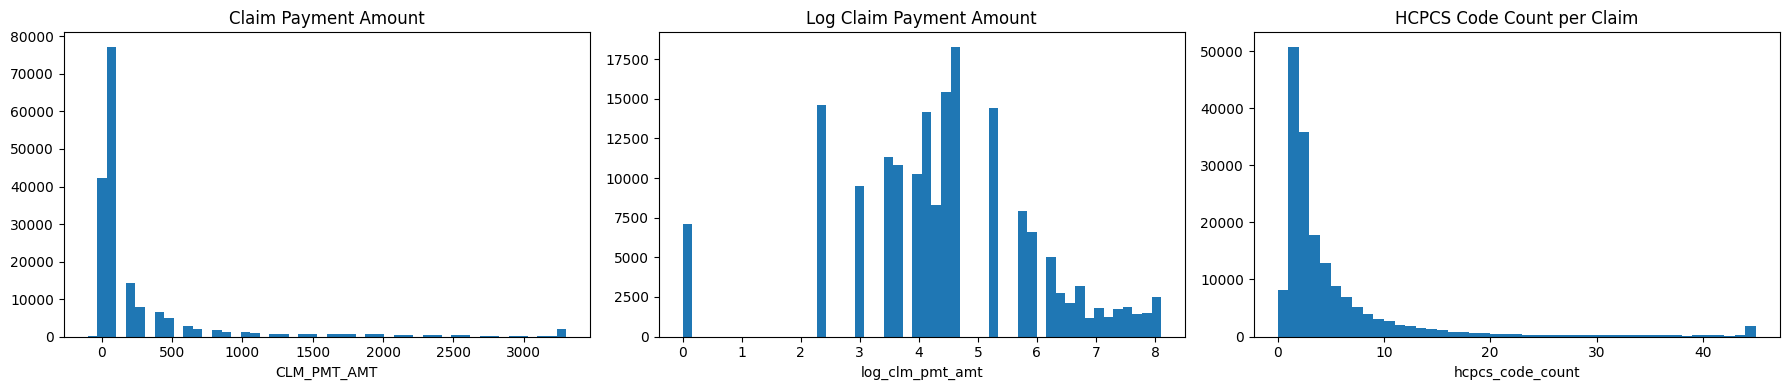

Saved figure to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/figures/02_baseline_feature_distributions.png


In [22]:
#Cell 18 - Create quick baseline plots for data understanding
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['CLM_PMT_AMT'].fillna(0), bins=50)
axes[0].set_title('Claim Payment Amount')
axes[0].set_xlabel('CLM_PMT_AMT')

axes[1].hist(df['log_clm_pmt_amt'].fillna(0), bins=50)
axes[1].set_title('Log Claim Payment Amount')
axes[1].set_xlabel('log_clm_pmt_amt')

axes[2].hist(df['hcpcs_code_count'].fillna(0), bins=range(0, int(df['hcpcs_code_count'].max()) + 2))
axes[2].set_title('HCPCS Code Count per Claim')
axes[2].set_xlabel('hcpcs_code_count')

plt.tight_layout()

figure_path = FIGURES_DIR / '02_baseline_feature_distributions.png'
plt.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()

print('Saved figure to:', figure_path)


In [23]:
#Cell 19 - Export notebook run summary
run_summary = {
    'raw_csv_path': str(RAW_CSV_PATH),
    'raw_shape': [int(df_raw.shape[0]), int(df_raw.shape[1])],
    'analytical_table_path': str(analytical_parquet_path),
    'model_feature_table_path': str(model_features_parquet_path),
    'feature_dictionary_path': str(feature_dictionary_path),
    'schema_audit_path': str(schema_out_path),
    'feature_audit_path': str(feature_audit_path),
    'grain_check_path': str(grain_check_path),
    'figure_path': str(figure_path),
}

run_summary_path = NOTEBOOK_EXPORTS_DIR / '02_data_preparation_run_summary.json'
with open(run_summary_path, 'w', encoding='utf-8') as f:
    json.dump(run_summary, f, indent=2)

print('Saved run summary to:', run_summary_path)
print(json.dumps(run_summary, indent=2))


Saved run summary to: /content/drive/MyDrive/NyanThesisAnomaly/outputs/notebook_exports/02_data_preparation_run_summary.json
{
  "raw_csv_path": "/content/drive/MyDrive/NyanThesisAnomaly/data/raw/kaggle_cms_desynpuf_2010_outpatient_claims/desynpuf_outpatient_claims_2010_filtered.csv",
  "raw_shape": [
    175005,
    76
  ],
  "analytical_table_path": "/content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_analytical_table_v1.parquet",
  "model_feature_table_path": "/content/drive/MyDrive/NyanThesisAnomaly/data/processed/claims_model_features_v1.parquet",
  "feature_dictionary_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_feature_dictionary.csv",
  "schema_audit_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_raw_schema_and_missingness.csv",
  "feature_audit_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_model_feature_audit.csv",
  "grain_check_path": "/content/drive/MyDrive/NyanThesisAnomaly/outputs/tables/02_claim_gr

## Notebook Summary: Data Preparation and Claim-Level Feature Engineering

This notebook served the purpose of preparing outpatient claims data and engineering baseline features for subsequent analysis. The key objectives achieved were:

- **Loading Data**: Loaded the outpatient claims table from Google Drive.
- **Data Auditing**: Audited schema, identified missingness, and checked the claim grain to ensure data quality and consistency.
- **Data Standardization**: Standardized dates, numeric fields, and cleaned code fields by handling string placeholders.
- **Feature Engineering**: Built a clean, claim-level analytical table and created thesis-core baseline features, including temporal, code-count, and payment-derived features.
- **Output Generation**: Saved reusable processed outputs, including analytical tables and a model feature table, for later notebooks.

### Processes Performed:
1.  **Load libraries and project paths**.
2.  **Load raw outpatient claims dataset**.
3.  **Inspect schema, data types, and missingness**.
4.  **Define column groups** for various data types (IDs, dates, payments, diagnoses, procedures, HCPCS, admits).
5.  **Make a working copy and standardize string placeholders** to `pd.NA`.
6.  **Convert dates** to datetime objects and derive a clean claim date range.
7.  **Convert payment-related columns** to numeric types.
8.  **Check claim grain** and create a unique `CLAIM_KEY`.
9.  **Create temporal baseline features** such as claim duration, year, month, day of week, and weekend/same-day flags.
10. **Count diagnosis, procedure, and HCPCS code usage** per claim and create flags for presence.
11. **Create core payment-derived baseline features** like total beneficiary liability, zero payment flags, log-transformed payment amounts, and high/extreme cost flags.
12. **Keep anchor code fields** (primary/secondary diagnosis, procedure, HCPCS, admitting diagnosis) for later modeling.
13. **Build the cleaned analytical table** with selected columns.
14. **Create a thesis-core model feature table**.
15. **Audit the thesis-core feature table** for data types, missingness, and uniqueness.
16. **Save processed analytical outputs** as Parquet and CSV files.
17. **Save a feature dictionary** describing the model features.
18. **Create quick baseline plots** for data understanding and save the figure.
19. **Export notebook run summary** to a JSON file.

### Key Output Tables:

#### Date Quality Summary (`date_quality`)
```
{date_quality_md}
```

#### Payment Summary (`payment_summary`)
```
{payment_summary_md}
```

#### Claim Grain Check (`grain_check`)
```
{grain_check_md}
```

#### Model Feature Audit (`feature_audit`)
```
{feature_audit_md}
```

#### Feature Dictionary (`feature_dictionary`)
```
{feature_dictionary_md}
```

### Saved Output File Paths:

- **Raw CSV Path**: `{raw_csv_path}`
- **Analytical Table (Parquet)**: `{analytical_table_path}`
- **Model Feature Table (Parquet)**: `{model_feature_table_path}`
- **Feature Dictionary (CSV)**: `{feature_dictionary_path}`
- **Schema Audit (CSV)**: `{schema_audit_path}`
- **Feature Audit (CSV)**: `{feature_audit_path}`
- **Claim Grain Check (CSV)**: `{grain_check_path}`
- **Baseline Feature Distributions Plot (PNG)**: `{figure_path}`

